**Practica_2_Parte_2:**

presentado por: Karly Tarazona, Luis Montoya

**procedimiento**

1. Exploración y descripción de la base de datos

Realice una exploración general de la base de datos proporcionada. Identifique y describa:

• Número total de registros y sujetos. 

• Tipos de arritmias o clases disponibles. 

• Número de sujetos o registros pertenecientes a cada grupo. 

• Número de canales disponibles y sus correspondientes derivaciones. 

• Frecuencia de muestreo y duración de los registros. 

Presente esta información mediante tablas y, cuando sea pertinente, gráficos que permitan visualizar 
la distribución de los datos entre las diferentes clases

1. EXPLORACIÓN Y DESCRIPCIÓN DE LA BASE DE DATOS
• Número total de registros y sujetos: 10646
• Tipos de arritmias o clases disponibles: ['ST', 'AFIB', 'AF', 'SVT', 'SA', 'SB', 'SR', 'AT', 'AVNRT', 'SAAWR', 'AVRT']
• Número de canales disponibles: 12
• Derivaciones correspondientes: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
• Frecuencia de muestreo (Fs): 500 Hz
• Duración promedio de los registros: 10.00 segundos

--- Tabla: Número de sujetos por cada grupo ---


,Tipo de Arritmia / Clase,Número de Sujetos / Registros
0,SB,3889
1,SR,1826
2,AFIB,1780
3,ST,1568
4,SVT,587
5,AF,445
6,SA,399
7,AT,121
8,AVNRT,16
9,AVRT,8


C:\Users\Acer\AppData\Local\Temp\ipykernel_9812\3080415331.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_grupos, x='Tipo de Arritmia / Clase', y='Número de Sujetos / Registros', palette='Blues_r')


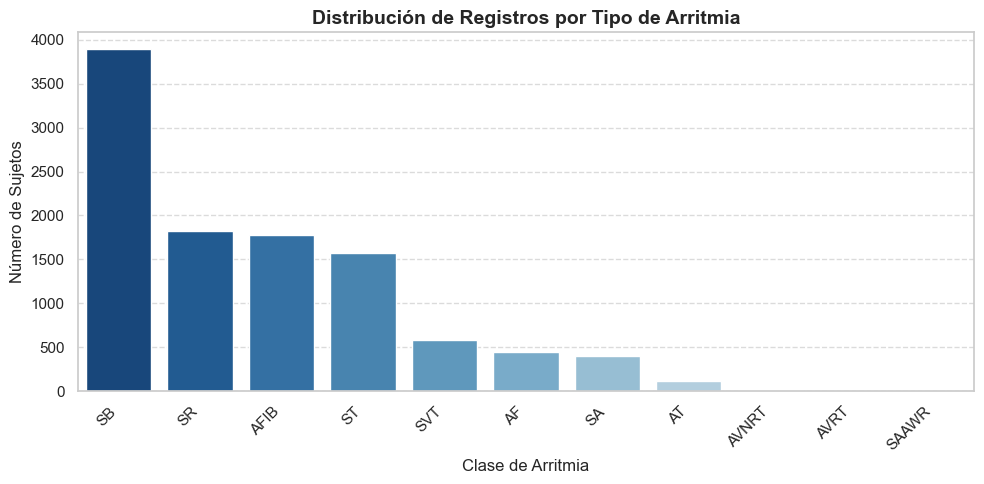

In [17]:
import os
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


RUTA_CARPETA = (r"C:\Users\Acer\Desktop\Biosenales_Luis_Montoya\Biosenales_Luis_Montoya_Karly_Tarazona-1\practica_2\ECGDataDenoised")        
DIAGNOSTICS_PATH = (r"C:\Users\Acer\Desktop\Biosenales_Luis_Montoya\Biosenales_Luis_Montoya_Karly_Tarazona-1\practica_2\Diagnostics.xlsx")  
FS = 500                                         # Frecuencia de muestreo estándar (Hz)
DERIVACIONES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


diagnostics = pd.read_excel(DIAGNOSTICS_PATH)

# Buscar todos los archivos CSV en la carpeta
archivos_csv = glob.glob(os.path.join(RUTA_CARPETA, '*.csv'))

registros_exploracion = []

for archivo in archivos_csv:
    filename_stem = Path(archivo).stem
    
    # Cruzar con el archivo maestro usando FileName
    subject_meta = diagnostics[diagnostics["FileName"] == filename_stem]
    
    if not subject_meta.empty:
        # Extraer el tipo de arritmia o ritmo (columna 'Rhythm' del maestro)
        arritmia = subject_meta["Rhythm"].values[0]
        
        # Leer el CSV para calcular muestras y duración
        df = pd.read_csv(archivo)
        num_muestras = len(df)
        duracion_seg = num_muestras / FS
        
        registros_exploracion.append({
            'Archivo': filename_stem,
            'Arritmia': arritmia,
            'Muestras': num_muestras,
            'Duracion_s': duracion_seg,
            'Canales': len(df.columns)
        })

# Crear DataFrame consolidado para la exploración
df_exploracion = pd.DataFrame(registros_exploracion)


print("==================================================")
print("1. EXPLORACIÓN Y DESCRIPCIÓN DE LA BASE DE DATOS")
print("==================================================")

# • Número total de registros y sujetos
total_registros = len(df_exploracion)
print(f"• Número total de registros y sujetos: {total_registros}")

# • Tipos de arritmias o clases disponibles
tipos_arritmias = df_exploracion['Arritmia'].unique().tolist()
print(f"• Tipos de arritmias o clases disponibles: {tipos_arritmias}")

# • Número de canales disponibles y sus correspondientes derivaciones
print(f"• Número de canales disponibles: {len(DERIVACIONES)}")
print(f"• Derivaciones correspondientes: {DERIVACIONES}")

# • Frecuencia de muestreo y duración de los registros
print(f"• Frecuencia de muestreo (Fs): {FS} Hz")
print(f"• Duración promedio de los registros: {df_exploracion['Duracion_s'].mean():.2f} segundos\n")

# • Número de sujetos o registros pertenecientes a cada grupo (Tabla)
conteo_grupos = df_exploracion['Arritmia'].value_counts().reset_index()
conteo_grupos.columns = ['Tipo de Arritmia / Clase', 'Número de Sujetos / Registros']

print("--- Tabla: Número de sujetos por cada grupo ---")
display(conteo_grupos)

# • Gráfico que permite visualizar la distribución de los datos entre las diferentes clases
plt.figure(figsize=(10, 5))
sns.barplot(data=conteo_grupos, x='Tipo de Arritmia / Clase', y='Número de Sujetos / Registros', palette='Blues_r')
plt.title("Distribución de Registros por Tipo de Arritmia", fontsize=14, fontweight='bold')
plt.xlabel("Clase de Arritmia", fontsize=12)
plt.ylabel("Número de Sujetos", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

2. Visualización y caracterización de las señales
Seleccione dos registros de dos tipos de arritmia. Realice una breve consulta de esas dos arritmias
y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud, 
frecuencia cardíaca y regularidad de los latidos.

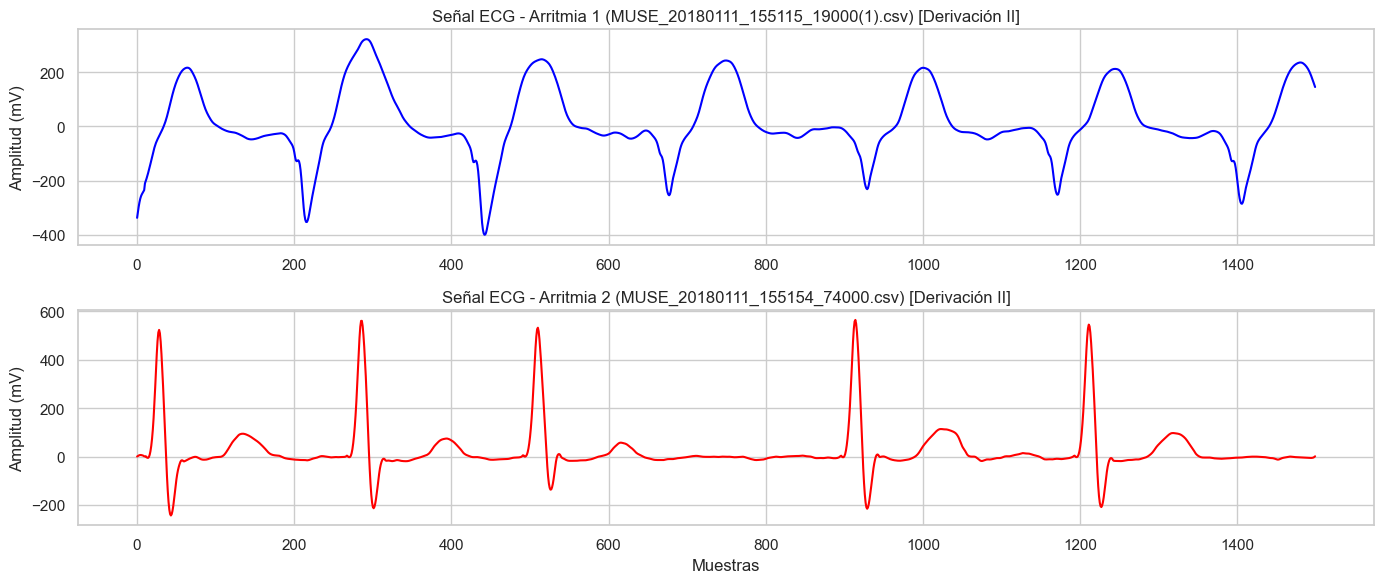

In [27]:

def visualizar_dos_arritmias(archivos_csv):
    
    if len(archivos_csv) < 2:
        print("Se necesitan al menos dos archivos para comparar.")
        return
    
    
    archivo_1 = archivos_csv[0]
    archivo_2 = archivos_csv[3]
    
    df1 = pd.read_csv(archivo_1)
    df2 = pd.read_csv(archivo_2)
    
    if len(df1.columns) == len(DERIVACIONES): df1.columns = DERIVACIONES
    if len(df2.columns) == len(DERIVACIONES): df2.columns = DERIVACIONES
    
    
    canal = 'II'
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(df1[canal].values[:1500], color='blue')
    plt.title(f"Señal ECG - Arritmia 1 ({os.path.basename(archivo_1)}) [Derivación {canal}]")
    plt.ylabel("Amplitud (mV)")
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(df2[canal].values[:1500], color='red')
    plt.title(f"Señal ECG - Arritmia 2 ({os.path.basename(archivo_2)}) [Derivación {canal}]")
    plt.xlabel("Muestras")
    plt.ylabel("Amplitud (mV)")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

visualizar_dos_arritmias(archivos_csv)

- **Arritmia_1:** (AFib) fibrilación auricular es un ritmo cardíaco irregular y a menudo acelerado que ocurre cuando las cavidades superiores del corazón laten de forma caótica, en un trazado con AFib los picos se presentan de forma completamente desorganizada y a tiempos desiguales. Además, la línea base entre cada latido deja de ser plana y se muestra temblorosa debido a la vibración caótica de las aurículas, tambien se presenta ausencia de ondas P.
Como se puede ver en la imagen la morfología es ancha y redondeada, esto se debe a que este es un corazón con RBBB (se reviso el archivo de diagnostico), la señal eléctrica que viaja hacia el ventrículo derecho se retrasa. Esto hace que los ventrículos se despolaricen de forma asincrónica, ensanchando drásticamente el complejo QRS, las aurículas están latiendo exactamente al doble de velocidad que los ventrículos y la señal tiene una amplitud enorme, con oscilaciones que van desde los +300 mV hasta los -400 mV viendose que toda la fuerza eléctrica está dominada por los ventrículos, tambien se evidencia que hay ausencia de onda p.

- **Arritmia_2:** (Bradicardias) El corazón late de forma demasiado lenta, habitualmente por debajo de los 60 latidos por minuto en reposo. El trazo electrocardiográfico es compatible con una pausa sinusal o un bloqueo sinoauricular intermitente, evidenciado por el cese transitorio de la actividad eléctrica cardíaca normal. Los complejos QRS son estrechos y conservan una morfología normal y se observa una frecuencia baja (bradicardia)

3. Análisis estadístico entre arritmias
Calcule y compare mediante un análisis descriptivo (box plots, diagramas de densidad, etc.) las 
siguientes características descriptivas: media, desviación estándar, valor máximo, valor mínimo, 
frecuencia cardíaca y el valor RMS. 
Formule una hipótesis nula y una hipótesis alternativa con las arritmias escogidas anteriormente.
Antes de aplicar una prueba estadística paramétrica, compruebe los supuestos necesarios para realizar 
una prueba t de Student. Si los supuestos se cumplen, realice la prueba t de Student para muestras 
independientes con el fin de determinar si existen diferencias estadísticamente significativas entre los 
grupos de arritmias. Si no se cumple el supuesto de normalidad o las condiciones necesarias para 
utilizar la prueba t, realice un análisis no paramétrico mediante la prueba U de Mann-Whitney, 
apropiada para comparar dos grupos independientes.
